In [ ]:
   #Muhammad Daniyal
   #DHC-9027



import yfinance as yf
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

In [ ]:
#LOAD HISTORICAL DATA
ticker = "AAPL"
df = yf.download(ticker, start="2020-01-01", end="2024-12-31", auto_adjust=True)
df.dropna(inplace=True)
print(f"✅ Loaded {len(df)} trading days for {ticker}")
print(df.head())

[*********************100%***********************]  1 of 1 completed

✅ Loaded 1257 trading days for AAPL
Price           Close       High        Low       Open     Volume
Ticker           AAPL       AAPL       AAPL       AAPL       AAPL
Date                                                             
2020-01-02  72.400497  72.460761  71.156659  71.409763  135480400
2020-01-03  71.696640  72.455958  71.472462  71.629145  146322800
2020-01-06  72.267944  72.306514  70.568518  70.819216  118387200
2020-01-07  71.928047  72.533087  71.708687  72.277571  108872000
2020-01-08  73.085098  73.386416  71.631544  71.631544  132079200


In [ ]:
#FEATURE ENGINEERING
df['Prev_Close']  = df['Close'].shift(1)          # Previous day's close
df['Price_Range'] = df['High'] - df['Low']         # Daily range (volatility)
df['MA_5']        = df['Close'].rolling(5).mean()  # 5-day moving average
df['MA_10']       = df['Close'].rolling(10).mean() # 10-day moving average
df['Vol_Change']  = df['Volume'].pct_change()      # Volume % change

df.dropna(inplace=True)  # Drop rows with NaN from rolling/shift

features = ['Open', 'High', 'Low', 'Volume',
            'Prev_Close', 'Price_Range', 'MA_5', 'MA_10', 'Vol_Change']

X = df[features]
y = df['Close']

print(f"\n Feature matrix shape: {X.shape}")
print(f" Target shape: {y.shape}")




📐 Feature matrix shape: (1248, 9)
🎯 Target shape: (1248, 1)


In [ ]:
#TIME-SERIES TRAIN / TEST SPLIT (80/20)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)


In [ ]:
#Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test).ravel()

In [ ]:
# --- Random Forest ---
rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test).ravel()

y_vals = np.array(y_test).ravel()

In [ ]:
# 5. EVALUATE MODELS
lr_rmse = np.sqrt(mean_squared_error(y_vals, lr_pred))
rf_rmse = np.sqrt(mean_squared_error(y_vals, rf_pred))
lr_r2   = r2_score(y_vals, lr_pred)
rf_r2   = r2_score(y_vals, rf_pred)

print("\n📊 MODEL PERFORMANCE")
print(f"{'Model':<22} {'RMSE':>10} {'R² Score':>12}")
print("-" * 46)
print(f"{'Linear Regression':<22} {lr_rmse:>9.2f} {lr_r2:>12.5f}")
print(f"{'Random Forest':<22} {rf_rmse:>9.2f} {rf_r2:>12.5f}")


📊 MODEL PERFORMANCE
Model                        RMSE     R² Score
----------------------------------------------
Linear Regression           0.96      0.99937
Random Forest               1.37      0.99871


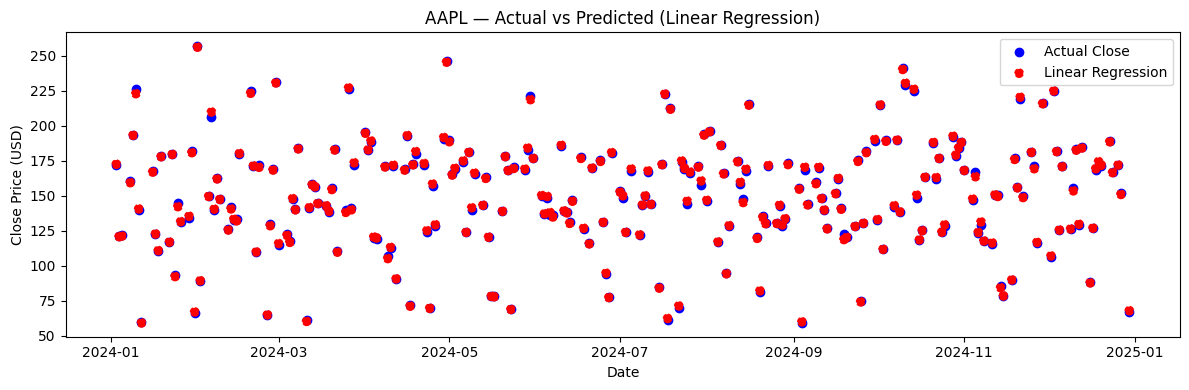

In [ ]:
#plotting Linear Regression
split = int(len(df) * 0.8)
test_dates = df.index[split:]
plt.figure(figsize=(12, 4))
plt.scatter(test_dates, y_vals,  label='Actual Close',       color='blue')
plt.scatter(test_dates, lr_pred, label='Linear Regression',  color='red',   linestyle='--')
plt.title('AAPL — Actual vs Predicted (Linear Regression)')
plt.xlabel('Date')
plt.ylabel('Close Price (USD)')
plt.legend()
plt.tight_layout()
plt.savefig('lr_plot.png')
plt.show()

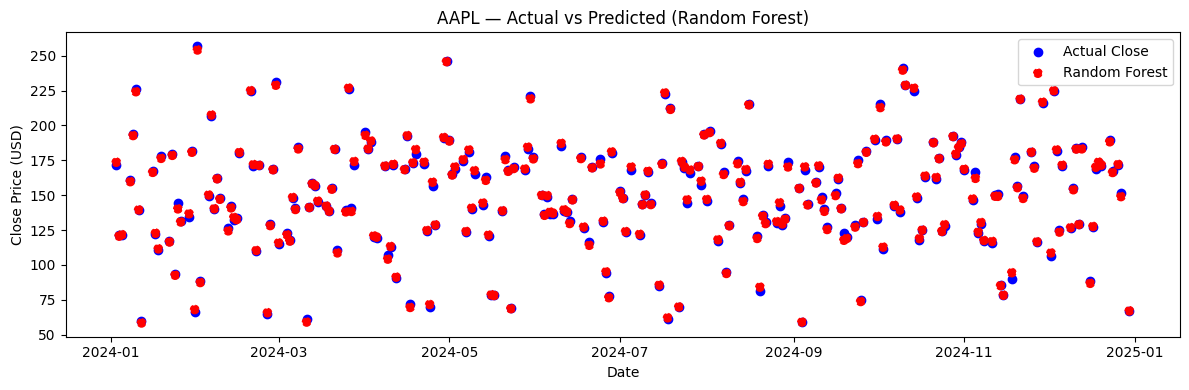

In [ ]:
#plotting random forest
plt.figure(figsize=(12, 4))
plt.scatter(test_dates, y_vals,  label='Actual Close',       color='blue')
plt.scatter(test_dates, rf_pred, label='Random Forest',  color='red',   linestyle='--')
plt.title('AAPL — Actual vs Predicted (Random Forest)')
plt.xlabel('Date')
plt.ylabel('Close Price (USD)')
plt.legend()
plt.tight_layout()
plt.savefig('rf_plot.png')
plt.show()